<a href="https://colab.research.google.com/github/ldaniel-hm/eml_tabular/blob/main/MonteCarloTodasLasVisitas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Q-Learning con Políticas epsilon_greedy**

In [1]:
%%capture
#@title Instalamos gym
!pip install 'gym[box2d]==0.20.0'
!pip install "gymnasium[toy-text]

In [2]:
import sys

if "google.colab" in sys.modules:
    print("Google Colab")
    !git clone #TODO
    %cd k_brazos/PATH_CLONADO #TODO

sys.path.append("src")
print(sys.path)

['C:\\Users\\Alberto\\anaconda3\\envs\\EML\\python311.zip', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\DLLs', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\Lib', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML', '', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\Lib\\site-packages', 'src']


In [3]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
from agent.q_learning import QLearning
from plotting import plot_stats, plot_episode_lengths
from IPython.display import clear_output
import time

In [4]:
seed = 123 # Se define una semilla fija
# Fijar la semilla en NumPy
np.random.seed(seed) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(seed) # Establece una instancia del generador de NumPy con la misma semilla

Generator(PCG64) at 0x1D7675DE500

In [5]:
# is_rainy=False evita ruido en los movimientos
# fickle_passenger=False para omitir un cambio de destino sobre las marcha del pasajero
env = gym.make("Taxi-v4", is_rainy=False, fickle_passenger=False, render_mode="rgb_array") 

num_episodes = 50000

q_learning_agent = QLearning(env=env, learning_rate=0.1, initial_epsilon=1.0, epsilon_decay=0.01, final_epsilon=0.05, discount_factor=0.95)


episode_lengths = []
list_stats = []

for episode in tqdm(range(num_episodes)):
    state, _ = env.reset(seed=seed)
    done = False
    
    episode_reward = 0
    episode_length = 0
    
    while not done:
        action = q_learning_agent.get_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        q_learning_agent.update(state, next_state, action, reward, terminated, truncated)
        state = next_state
        
        done = terminated or truncated
        episode_reward += reward
        episode_length += 1
    
    # Fin de episodio
    q_learning_agent.end_episode()
    q_learning_agent.decay_exploration()

    # Se guardan los promedios y la longitud del episodio para las gráficas posteriores
    list_stats.append(episode_reward)
    episode_lengths.append(episode_length)

    if episode % 5000 == 0 and episode != 0:
        print(f"Recompensa del episodio: {episode_reward:.2f}, epsilon: {q_learning_agent.epsilon:.3f}")

 11%|███████▉                                                                   | 5305/50000 [00:03<00:24, 1801.96it/s]

Recompensa del episodio: -6.00, epsilon: 0.050


 21%|███████████████▎                                                          | 10322/50000 [00:06<00:24, 1633.92it/s]

Recompensa del episodio: 6.00, epsilon: 0.050


 31%|██████████████████████▊                                                   | 15405/50000 [00:09<00:23, 1483.72it/s]

...

 80%|███████████████████████████████████████████████████████████▍              | 40202/50000 [00:33<00:09, 1070.40it/s]

Recompensa del episodio: 6.00, epsilon: 0.050


 90%|██████████████████████████████████████████████████████████████████▊       | 45123/50000 [00:38<00:04, 1047.93it/s]

Recompensa del episodio: 3.00, epsilon: 0.050


100%|██████████████████████████████████████████████████████████████████████████| 50000/50000 [00:42<00:00, 1168.54it/s]


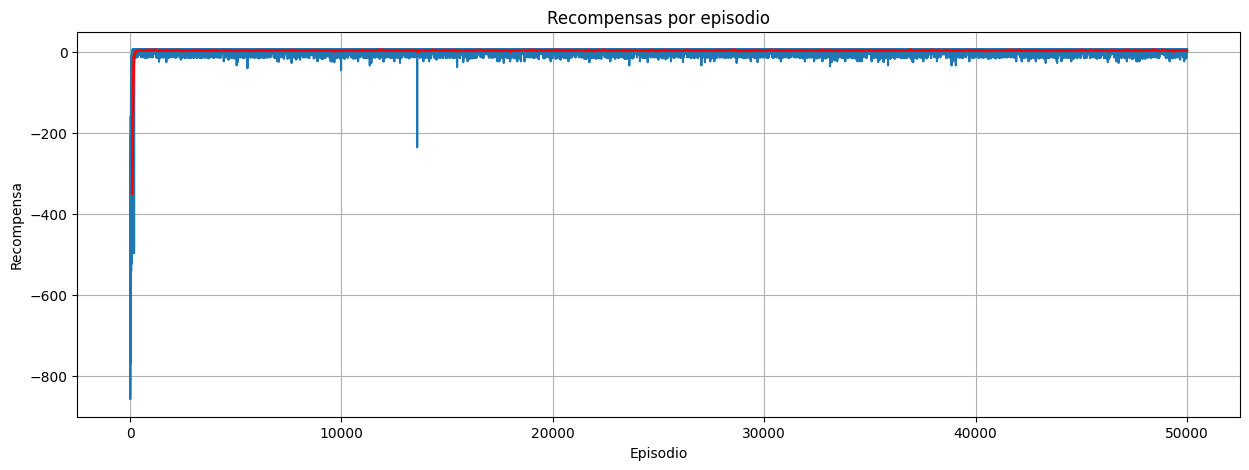

Máxima proporcion: 6


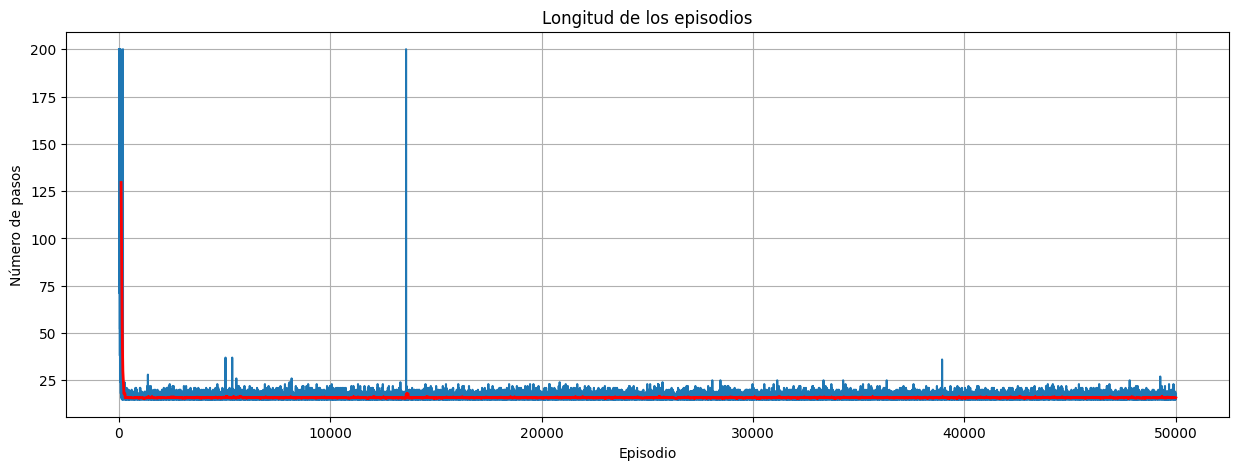

In [6]:
plot_stats(list_stats)
print(f"Máxima proporcion: {max(list_stats)}")
plot_episode_lengths(episode_lengths)

In [7]:
print("Valores Q para cada estado:\n", q_learning_agent.get_q_table())

Valores Q para cada estado:
 {441: array([ -4.88288087,  -1.46835079,  -6.20055496,  -5.53567935,
       -13.01919727, -12.94999978]), 341: array([ -2.39493325,  -0.49300084,  -1.46835079,  -0.49300084,
       -10.46835079, -10.46835079]), 421: array([ -5.98813414,  -0.49300084,  -5.34594992,  -4.37325452,
       -12.61497119, -13.29715987]), 321: array([-1.46835079,  0.53368333, -1.46835079, -0.49300084, -9.49300084,
       -9.49300084]), 221: array([-0.49300084,  1.61440351, -0.49300084,  1.61440351, -8.46631667,
       -8.46631667]), 241: array([-1.46858604, -1.46939015, -1.46930296,  0.53368333, -9.49301452,
       -9.49305221]), 261: array([ -6.7307764 ,  -6.70411643,  -6.77441012,  -0.49307926,
       -12.82339159, -13.08258069]), 201: array([ -4.53750542,   2.75200369,  -2.10311176,  -4.2026464 ,
       -10.12563377, -10.36398475]), 101: array([ 1.61440351,  3.94947757,  1.61440351,  2.75200369, -6.24799631,
       -6.24799631]), 301: array([ -5.63729113,  -1.24943745,  -5.61934

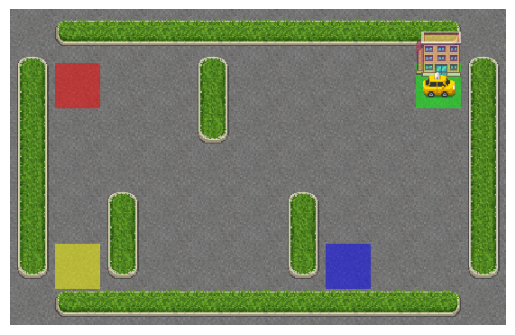

Reward final: 6
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


Acciones: NORTH -> WEST -> NORTH -> NORTH -> WEST -> PICKUP -> SOUTH -> SOUTH -> EAST -> EAST -> EAST -> NORTH -> NORTH -> EAST -> DROPOFF


In [8]:
state, _ = env.reset(seed=seed)
ACTION_NAMES = {0: "SOUTH", 1: "NORTH", 2: "EAST", 3: "WEST", 4: "PICKUP", 5: "DROPOFF"}

actions_taken = []

done = False
rewards = 0

while not done:
    frame = env.render()

    clear_output(wait=True)
    plt.imshow(frame)
    plt.axis("off")
    plt.show()

    action = q_learning_agent.get_action(state, training=False) # training False asegura np.argmax(self.q_values[state])
    actions_taken.append(ACTION_NAMES[action])

    state, reward, terminated, truncated, _ = env.step(action)
    rewards += reward

    done = terminated or truncated

    time.sleep(0.25)

print("Reward final:", rewards)
# Mostramos la representación real que la visual puede confundir
env_ansi = gym.make("Taxi-v4", render_mode="ansi")
state, _ = env_ansi.reset(seed=seed)
print(env_ansi.render())
print("Acciones:", " -> ".join(actions_taken))